Group members: 
Srimann Nambakkam (sn29939)
Amaan Desai (ad55777)
Walt Truelove (wjt582)

# Section 1: Introduction & Model Selection

(USED CLAUDE TO HELP UNDERSTAND THE ODE BETTER)

For my real-world system, I chose to model the vehicle dynamics of a quarter-car suspension system - a widely used model in the engineering world to model the dynamics of a single wheel-damper system belonging to one of the car's wheels. This model isolates the vertical motion of the sprung mass as a spring and damper in parallel act against the force inputs from the road.  

This is governed by the spring-mass second-order ordinary differential equation (my'' + cy' + ky = 0). We can now convert this second-order ODE into a system of first order ODEs. Through rearranging the second-order ODE and the creation of the variables y1 and y2, we can set (y1)' = y2 and (y2)'= - (k/m)(y1) - (c/m)(y2).

With acceleration being the second derivative of position (y), my'' can be represented as ma (mass * acceleration) which essentially represents the net force that is acting upon the sprung mass system. The c is the damping coefficient, which acts as a viscous/drag/friction force upon the system. This coefficient is attatched to y' which represents the vertical velocity of the system. Together, the cy' term represents a damping force of the suspension's shock absorber. This term comes in a similar form as Friction/Viscous/Drag forces where the magnitude of the force is directly proportional to the velocity of the system with a coefficient (damping coefficient (c) in this case) scaling it the velocity by a certain scale to represent the force. Lastly, the ky term is representative of hooke's law for ideal springs. In this case, k is the suspension spring stiffness and can be thought of as a spring constant. Additionally, y is the vertical displacement of the system from its equilibrium position. Together, the force from the spring can be represented by the ky term and its magnitude directly proportional to the vertical displacement (y) and scaled by the spring stiffness (k).

# Section 2: Parameter Research and Justification

Parameters

m = 250 kg (kilgorams) (vehicle mass / 4)   (Kong et al. 2019 [1])

c = 1,000 N*s/m (Newtons, seconds, meters) (Prabhakar et al. 2015 [2])

k = 20,000 N/m (Newtons, meters)  (Kong et al. 2019 [1])

The "m" and "k" parameters are from a study done by Yat Sheng Kong in 2019 where Kong was researching optimal suspension system parameters to test for spring fatigue life. The k is well within the range for typical springs in car suspension systems. The mass is a little less than a fourth of typical passenger sedan vehicles but I ended up using 250 kg as that is what the paper cited. The "c" parameter is from a research study from S.Prabhakar in 2015 where suspension system parameters were studied for different road profiles. The type of car these two studies were done for are passenger sedans such as Toyota Camrys or Honda Civics. The parameters are typical for these types of cars, which is why we felt that they would make sense to use in this situation.

Initial Conditions
y[0] / y1[0]  = 0.07 m 
y'[0] / y2[0] = 0 m/s

The situation I am trying to model is the behavior of the mass sprung system after passing over a speed bump. After a car passes a speed bump, the car's suspension system works to restabilize the car back to an equilibrium. This is one of the keys to stability in vehicles. The initial state of my time frame occurs when the vertical displacement is at a maximum. At this state, the velocity is momentarily equal to zero, hence the y2[0] = 0. The average speed bump heights are between the 5-10 cm range so I arbitrarily picked a value in the range to set y1[0] = 0.07 m. Lastly, I often use a time interval of t = 0 seconds to t = 5 seconds. I chose this as I felt 5 seconds is a realistic time interval for a car's suspension system to respond to the external force and stabilize the car. Additionally, this interval would allow for the oscillations to be shown and the system to return back to equilibrium. With the system's parameters set and initial condition defined, the system of linear first-order differential equations can be solved.

CITATIONS

Kong, Yat Sheng, et al. “Determining Optimal Suspension System Parameters for Spring Fatigue Life Using Design of Experiment.” Mechanics & Industry, vol. 20, no. 6, 2019, p. 621, www.mechanics-industry.org/articles/meca/full_html/2019/06/mi180235/mi180235.html, https://doi.org/10.1051/meca/2019034.

Prabhakar, S, and K Arunachalam. National Conference on Recent Trends and Developments in Sustainable Green Technologies Journal of Chemical and Pharmaceutical Sciences Www.jchps.com SIMULATION and ANALYSIS of PASSIVE SUSPENSION SYSTEM for DIFFERENT ROAD PROFILES with VARIABLE DAMPING and STIFFNESS PARAMETERS. 2015.

# Section 3: Numerical Methods Implementation 

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# constants in the ODE
m = 250.0      # kg
c = 1000.0     # N·s/m
k = 20000.0    # N/m
# Initial conditions 
y0 = 0.07      # initial displacement (m)
v0 = 0.0       # initial velocity (m/s)

# getting the exact solution
wn = np.sqrt(k / m)
zeta = c / (2 * np.sqrt(m * k))
wd = wn * np.sqrt(1 - zeta**2)

#function to return the exact y value for a given time input
def y_exact(t):
    return y0 * np.exp(-zeta * wn * t) * (np.cos(wd * t) + (zeta / np.sqrt(1 - zeta**2)) * np.sin(wd * t))

# Fine time grid for the exact reference curve
t_exact = np.linspace(0, 5, 4000)
# start and end time
t_start = 0
t_end = 5
# two arrays for step sizes 
#array for euler's forward
h_arr = [0.005,0.01,0.05]
# added a couple larger step sizes to RK4 since it was performing very well with the first 3
h_arr_2 = [0.005,0.01,0.05,0.1,0.15]


In [102]:
# functions for euler's forward - position and velocity.

def euler_forward(t_start, t_end, h, plot_type="position"):
    # number of steps and time array
    num_steps = int((t_end - t_start) / h)
    t_values = np.linspace(t_start, t_end, num_steps + 1)

    # state arrays
    y1_values = np.zeros(num_steps + 1)  # position
    y2_values = np.zeros(num_steps + 1)  # velocity

    # initial conditions
    y1_values[0] = y0
    y2_values[0] = v0

    # Euler loop
    for i in range(num_steps):
        y1_values[i+1] = y1_values[i] + h * y2_values[i]
        y2_values[i+1] = y2_values[i] + h * (-(c/m)*y2_values[i] - (k/m)*y1_values[i])

    # plotting decision
    if plot_type == "position":
        plt.plot(t_values, y1_values, label= f'h = {h}')
    elif plot_type == "velocity":
        plt.plot(t_values, y2_values, label= f'h = {h}')
    elif plot_type == "phase portrait":
        plt.plot(y1_values,y2_values, label =f' h = {h}')
    elif plot_type == "absolute error":
        #calculating exact solution
        exact_sol = y_exact(t_values)
        #calculating absolute error
        error = np.abs(exact_sol - y1_values)
        #plotting time vs error
        plt.plot(t_values, error, label=f'h = {h}')
    else:
        raise ValueError("plot_type is not valid")

In [103]:
#functions for RK4

#initial conditions of vector
y0_vec = np.array([y0, v0])

#system of linear ODEs
def f(t, y):
    y1_rk = y[0]  # displacement
    y2_rk = y[1]  # velocity
    
    #solving for derivatives based on given relations in the system.
    dy1dt_rk = y2_rk
    dy2dt_rk = -(c/m)*y2_rk - (k/m)*y1_rk

    return np.array([dy1dt_rk, dy2dt_rk])

# rk4 function
def rk4(f, y0_vec, t_start, t_end, h):
    
    #creating arrays for time and position/velocity vector
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros((len(t_values), len(y0_vec)))
    
    #setting initial values of vector
    y_values[0] = y0_vec

    # getting the four slopes (at beginning, at midpoint based off k1, at midpoint based off k2, slope at endpoint) 
    # looping across the entire time array
    for i in range(1, len(t_values)):
        #using the previous data points
        t = t_values[i - 1]
        y = y_values[i - 1]
        
        #calculating 4 slopes
        k1 = h * f(t, y)
        k2 = h * f(t + h/2, y + k1/2)
        k3 = h * f(t + h/2, y + k2/2)
        k4 = h * f(t + h, y + k3)
        #updating the values in the position/velocity vector using a weighted sum
        y_values[i] = y + (k1 + 2*k2 + 2*k3 + k4) / 6

    return t_values, y_values

### Brief Description of Implimentation approach
EULER'S FORWARD

The function we made for euler's forward took in arguments of an initial time, a final time, and a step size (h). For my implimentation of euler's forward method, I began by calculating the number of steps that the method would take based on the step size of that run. This allowed me to initialize an array that held all of the time values I would pass through the euler's forward loop. The values in this array would change based off the step size chosen for the given run. 

Then, I initialized two zero arrays of that were the same length of the time array. These two arrays will hold the values of y1 and y2 as the Euler's method runs. Although normally we would only have to initialize one array, we initialize two arrays since we are dealing with a system of 2 linear ODEs. Then, we set the intial conditions a y0 and v0. These initial conditions were based off realistic values. 

Then, we looped over a for loop in the range of our total steps. Each loop updated the [i+1] value based off the conditions of the current [i] values. The h in this case corresponded to a delta time. After the loop finished, we plotted the values of our approximation against the time values. Then, we used a for loop  to loop across all the h values in our array of step sizes. This plotted an approximation for all of our step sizes. We did the same thing for plotting the velocity except we used the y2 values in our 'plt.plot' function as y2 represents the first derivative of y1 where y1 represents position.

RK4 METHOD

The function f(t, y) takes the current time and state vector, then returns the derivatives of both state variables. The first derivative is velocity, and the second derivative is acquired from a rearrangement of the initial second order ODE. It returns an array that gives the derivatives of y1 and y2.

Then, the rk4 function takes in multiple inputs consisting of the function f, an initial state vector, a start time, end time, and step size. It begins by creating a time array, and a two columned array to store position and velocity. Then, it assigns the initial value to the first spot in the previously initialized array. While looping over each time step, the function calculates the four slope estimates using the previous iteration's values for t and the y vector. Then, it combines them using a weighted average and updates the values in the main position/velocity array.

After defining the two functions, we impliment a for loop that loops over all the step sizes in an array consisting of different step sizes. When plotting position vs time, we use the first column of the two-columned array returned by the rk4 function. We use the second column when plotting velocity vs time.

# Section 4: Solutions and Comparison

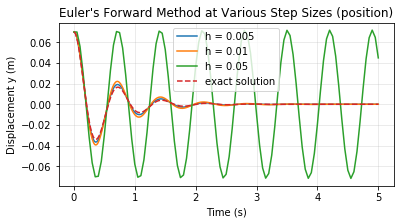

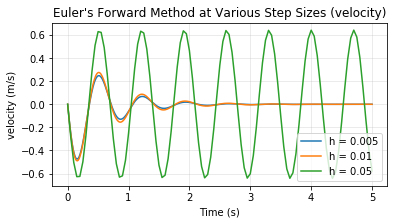

In [104]:
#plotting position and velocity for euler's forward

#configuring figure size
plt.figure(figsize=(6, 3))
# looping over all the step sizes    
for h in h_arr:
    euler_forward(t_start,t_end,h,"position")
# plotting exact solution
plt.plot(t_exact, y_exact(t_exact), '--', label='exact solution')    
plt.xlabel('Time (s)')
plt.ylabel('Displacement y (m)')
plt.title("Euler's Forward Method at Various Step Sizes (position)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6, 3))
#looping over all step sizes 
for h in h_arr:
    euler_forward(0,5,h,"velocity")
#setting up a good plot
plt.xlabel('Time (s)')
plt.ylabel('velocity (m/s)')
plt.title("Euler's Forward Method at Various Step Sizes (velocity)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

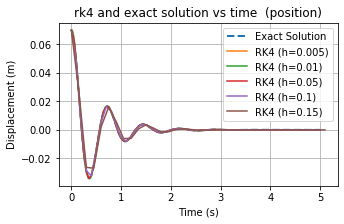

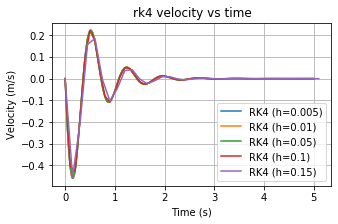

In [105]:
# configuring the plot
plt.figure(figsize=(5, 3))
# Exact solution
plt.plot(t_exact, y_exact(t_exact), '--', linewidth=2, label="Exact Solution")
# rk4 solutions for different step sizes and plotting
for h in h_arr_2:
    t_vals, y_vals = rk4(f, y0_vec, t_start, t_end, h)
    plt.plot(t_vals, y_vals[:, 0], label=f"RK4 (h={h})")

# setting up good plot
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("rk4 and exact solution vs time  (position)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5, 3))
#plotting velocity vs time now
for h in h_arr_2:
    t_vals1, y_vals1 = rk4(f, y0_vec, t_start, t_end, h)
    plt.plot(t_vals1, y_vals1[:, 1], label=f"RK4 (h={h})")
    
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("rk4 velocity vs time")
plt.legend()
plt.grid(True)
plt.show()

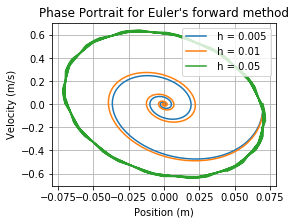

In [106]:
#phase portrait euler
plt.figure(figsize=(4, 3))
for h in h_arr:
    euler_forward(0,5,h,plot_type="phase portrait")
    
plt.xlabel("Position (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Portrait for Euler's forward method")
plt.legend()
plt.grid(True)
plt.show()

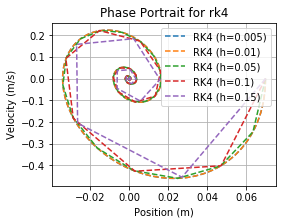

In [107]:
#phase portrait RK4

plt.figure(figsize=(4, 3))
for h in h_arr_2:
    t_vals2, y_vals2 = rk4(f, y0_vec, t_start, t_end, h)
    plt.plot(y_vals2[:,0], y_vals2[:, 1], '--', label=f"RK4 (h={h})")

plt.xlabel("Position (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Portrait for rk4")
plt.legend()
plt.grid(True)
plt.show()

### Discussion of the Phase Portraits 

(EULER)
It is interesting to see these phase portraits. Whether stable or unstable, they both seem to have a spiral-like behavior. It makes sense that the stable approximation spiral into (0,0) as both position and velocity eventually converge to 0 in the stable approximations run. Interestingly, the unstable run of euler's forward with h = 0.05 didn't end up converging and the phase portrait seems to be a circular figure. This makes sense as the approximation showed a seemingly-forever oscillation.

(RK4)
These phase portraits all make sense as all these approximations were stable and all of these phase portraits spiraled towards (0,0).

### Visual differences between the methods.

One of the differences that I see between the two methods is in the manner in which the two models are deviating from the analytical solution. When looking at Euler's forward method, the oscillations seem to follow the same period as the analytical solution, but tend to have greater amplitudes as the step size increases. On the other hand, the RK4 method seems to match the amplitude of the analytical solution pretty well. However, the RK4 method, especially at greater step sizes, seems to separate forward from the analytical solution, signifying discrepancies in the period of the approximation compared to the analytical solution. Additionally, the behavior of the unstable approximations differed between the two. This discrepancy is best displayed in the following plots I make in the next section, where I specifically plot for stability. RK4 at h = 0.35 and Euler's forward at h = 0.06 displayed unstable approximations. However, when Euler's forward approximation was unstable, it continued to oscillate as t kept increasing, each subsequent oscillation with a greater amplitude. On the other hand, when the RK4 approximation was unstable, it seemed to just increase following an exponential nature with no visible oscillations. 

# Section 5: Stability Analysis

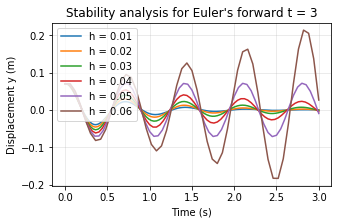

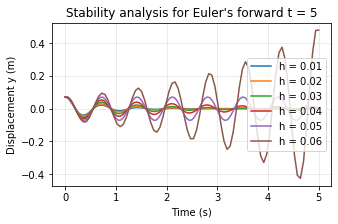

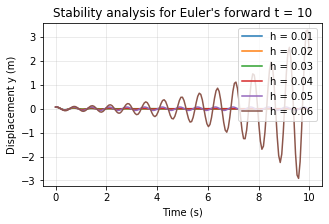

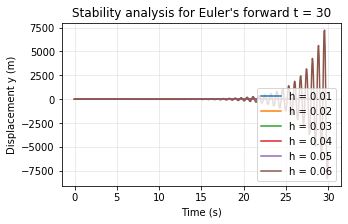


Step size h = 0.01
Update matrix B:
[[ 1.    0.01]
 [-0.8   0.96]]
Eigenvalues:
[0.98+0.08717798j 0.98-0.08717798j]
Magnitudes:
[0.98386991 0.98386991]
Solution is Stable

Step size h = 0.02
Update matrix B:
[[ 1.    0.02]
 [-1.6   0.92]]
Eigenvalues:
[0.96+0.17435596j 0.96-0.17435596j]
Magnitudes:
[0.97570487 0.97570487]
Solution is Stable

Step size h = 0.03
Update matrix B:
[[ 1.    0.03]
 [-2.4   0.88]]
Eigenvalues:
[0.94+0.26153394j 0.94-0.26153394j]
Magnitudes:
[0.97570487 0.97570487]
Solution is Stable

Step size h = 0.04
Update matrix B:
[[ 1.    0.04]
 [-3.2   0.84]]
Eigenvalues:
[0.92+0.34871192j 0.92-0.34871192j]
Magnitudes:
[0.98386991 0.98386991]
Solution is Stable

Step size h = 0.05
Update matrix B:
[[ 1.    0.05]
 [-4.    0.8 ]]
Eigenvalues:
[0.9+0.43588989j 0.9-0.43588989j]
Magnitudes:
[1. 1.]
Solution is Stable

Step size h = 0.06
Update matrix B:
[[ 1.    0.06]
 [-4.8   0.76]]
Eigenvalues:
[0.88+0.52306787j 0.88-0.52306787j]
Magnitudes:
[1.02371871 1.02371871]
Solut

In [108]:
# euler stability demonstration
h_arr_stability1 = [0.01,0.02,0.03,0.04,0.05,0.06]
t_arr = [3,5,10,30]
# looping over different time intervals and different step sizes to show stability changing with both parameters.
# using an extra h value of h = 0.06 to see another unstable approximation
for t in t_arr:
    plt.figure(figsize=(5, 3))
    for h in h_arr_stability1:
        euler_forward(0,t,h,plot_type = "position")
    
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement y (m)')
    plt.title(f"Stability analysis for Euler's forward t = {t}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# "A" matrix in x' = Ax
A = np.array([[0, 1],[-k/m, -c/m]])

#used claude to help with construction of stability matrix
for h in h_arr_stability1:
    B = np.eye(2) + h * A
    # Compute eigenvalues of update matrix
    eigvals = np.linalg.eigvals(B)
    magnitudes = np.abs(eigvals)
    print(f"\nStep size h = {h}")
    print("Update matrix B:")
    print(B)
    print("Eigenvalues:")
    print(eigvals)
    print("Magnitudes:")
    print(magnitudes)
    
    # Stability check
    if np.all(magnitudes <= 1):
        print("Solution is Stable")
    else:
        print("Solution may not be Entirely Stable ;)")

### Discussion of Stable vs Unstable behavior (Euler's Forward)

The plots above are meant to display the stability limits for Euler's Forward method with the defined system of First-order ODEs. Something that we noticed when playing around with the step sizes is that step size truly controls stability and time interval can make it seem like it controls stability. For this reason, we looped over both parameters to see how the maximum stable step size changes with different time intervals. The first time interval we used was from t=0 to t=3, an interval smaller than the standard one we've been using. In this plot, all of the step sizes except h = 0.06 seems to be on its way to converging to 0. The amplitude of each subsequent oscillation seems to be decreasing and one can infer that they will soon converge to 0. However, we noticed an interesting behavior with h = 0.06 as the oscillations seem to be increasing in amplitude. This was an early indicator that 0.06 is out of the system's stability bounds. This is supported with the following graphs. As the time intervals grew larger and larger, all of the step sizes except for h = 0.06 soon converge to --essentially-- 0. However, the oscillations for h = 0.06 grow at an incredibly fast rate reach above 4000 at around t = 29. This is a perfect display of the unstable nature of the system once the step size crosses h = 0.06. Overall, the system was stable and didn't grow in amplitude from step size h = 0.01 to h = 0.05. However, the system was unstable at step sizes h = 0.06 or greater as it oscillates out of control. The general accuracy of the system follows the stability limits as smaller step sizes are much more accurate but the approximation has less and less accuracy as step size increases and error balloons once the approximation is unstable.

The visual scan for stability was backed up by the calculating the rate of amplitude growth using the eigenvalues of the system matrix. The eigenvalue method evaluated whether the rate of growth was greater than 1 or less than/equal to 1. If the rate of growth was less than 1, this would deem the system as stable as it would lead the amplitude to eventually decay to 0. Magnitudes greater than 1 would imply instability. Step sizes up til 0.05 were deemed stable. h = 0.06 had a magnitude greater than 1, implying instability. Interestingly, h = 0.05 had a magnitude of exactly one which technical means that the approximation won't diverge to infinity but would rather oscillate forever. Overall, I would say the max stable step size is h = 0.05 as anything below will definitely converge and be stable.

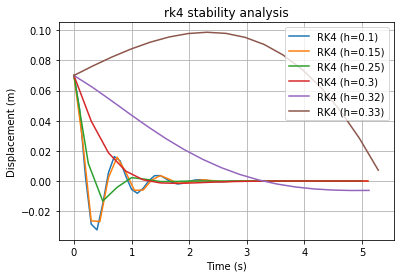

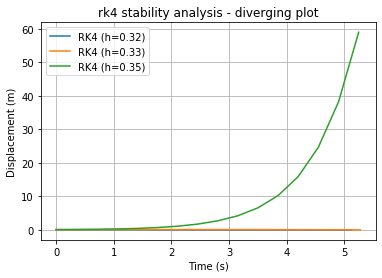

Eigenvalues of system: [-2.+8.71779789j -2.-8.71779789j]

Step size h = 0.1
 |R(z)| = 0.82051474358749
 |R(z)| = 0.82051474358749
rk4 method is stable for this step size.

Step size h = 0.15
 |R(z)| = 0.7425799620242927
 |R(z)| = 0.7425799620242927
rk4 method is stable for this step size.

Step size h = 0.25
 |R(z)| = 0.4583333333333334
 |R(z)| = 0.4583333333333334
rk4 method is stable for this step size.

Step size h = 0.3
 |R(z)| = 0.5642694391866347
 |R(z)| = 0.5642694391866347
rk4 method is stable for this step size.

Step size h = 0.32
 |R(z)| = 0.867189207050507
 |R(z)| = 0.867189207050507
rk4 method is stable for this step size.

Step size h = 0.33
 |R(z)| = 1.0701035012072422
 |R(z)| = 1.0701035012072422
rk is unstable for this step size.

Step size h = 0.35
 |R(z)| = 1.5738426082539347
 |R(z)| = 1.5738426082539347
rk is unstable for this step size.


In [109]:
# stability analysis for rk4

h_arr_stability2 = [0.1,0.15,0.25,0.3,0.32,0.33]
for h in h_arr_stability2:
    t_vals3, y_vals3 = rk4(f, y0_vec, t_start, t_end, h)
    plt.plot(t_vals3, y_vals3[:, 0], label=f"RK4 (h={h})")

# setting up good plot
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("rk4 stability analysis")
plt.legend()
plt.grid(True)
plt.show()
h_arr_stability3 = [0.32,0.33,0.35]
for h in h_arr_stability3:
    t_vals4, y_vals4 = rk4(f, y0_vec, t_start, t_end, h)
    plt.plot(t_vals4, y_vals4[:, 0], label=f"RK4 (h={h})")

# setting up good plot
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("rk4 stability analysis - diverging plot")
plt.legend()
plt.grid(True)
plt.show()

#USED CHATGPT TO HELP WITH SOME OF THE UNDERSTANDING OF THE STABILITY CHECK AND IMPLIMENTING OF THE CODE STUCTURE
# combined array of stability 2 and 3 for a single stability analysis.
h_arr_stability23 = [0.1,0.15,0.25,0.3,0.32,0.33,0.35]
# Eigenvalues of the system
eigenvalues_rk = np.linalg.eigvals(A)
print(f"Eigenvalues of system: {eigenvalues_rk}")

# RK4 stability function
def rk4_stability_function(z):
    return 1 + z + z**2/2 + z**3/6 + z**4/24

# Check RK4 stability for each h
for h in h_arr_stability23:
    print(f"\nStep size h = {h}")
    for lam in eigenvalues_rk:
        z = h * lam
        R = rk4_stability_function(z)
        magnitude = np.abs(R)
        print(f" |R(z)| = {magnitude}")
    if magnitude > 1:
            print("rk is unstable for this step size.")
    else:
            print("rk4 method is stable for this step size.")

### RK4 Stability discussion

Plots displaying the stable vs unstable behavior of the rk4 method are shown above. Immediately, we can see that the rk4 method can tolerate a much higher step size than Euler's forward. While instability came at around h = 0.06 for Euler's forward, we didn't see signs of instabiliy for rk4 until h = 0.3. Ultimately, complete divergence came at h = 0.35 as the displacement of the system exponentially grew. 

The rk4 stability results show that the method remains stable - with ∣R(z)∣<1 for all eigenvalues - at h values up til h = 0.32. However, the R(z) at h = 0.33 and above exceeds 1, signifying instability within the model. Somewhere between 0.32 and 0.33 is where the stability bound lies for the rk4 method on this system of ODEs.

Again, accuracy decreased when step size increased and ballooned when the step size left the stability bounds.

The results from both the eigenvalue method and a visual scan of the graphs validate the stability bounds to be h < ~0.33 and the maximum stable step size is around 0.32.

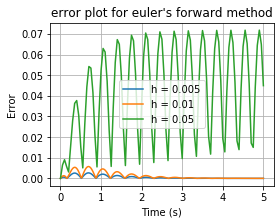

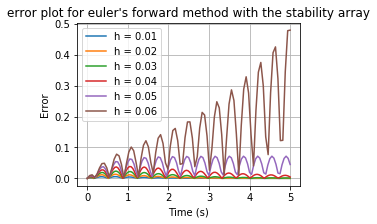

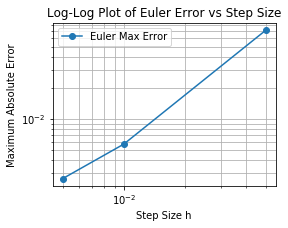

Euler convergence slope: 1.4540682610449875


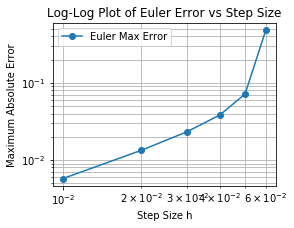

In [111]:
# new function for the log-log plot
def euler_forward_max_error(t_start, t_end, h):
    num_steps = int((t_end - t_start) / h)
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    y1_values = np.zeros(num_steps + 1)
    y2_values = np.zeros(num_steps + 1)
    y1_values[0] = y0
    y2_values[0] = v0
    for i in range(num_steps):
        y1_values[i+1] = y1_values[i] + h * y2_values[i]
        y2_values[i+1] = y2_values[i] + h * (-(c/m)*y2_values[i] - (k/m)*y1_values[i])
    exact_sol = y_exact(t_values)
    error = np.abs(exact_sol - y1_values)
    max_error = np.max(error)

    return max_error  
#looping over step size
plt.figure(figsize=(4, 3))
for h in h_arr:
    euler_forward(0,5,h,plot_type = "absolute error")

plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("error plot for euler's forward method")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(4, 3))
for h in h_arr_stability1:
    euler_forward(0,5,h,plot_type = "absolute error")

plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("error plot for euler's forward method with the stability array")
plt.legend()
plt.grid(True)
plt.show()

# method for log-log plot
euler_max_errors = []
for h in h_arr:
    max_error = euler_forward_max_error(t_start, t_end, h)
    euler_max_errors.append(max_error)

plt.figure(figsize=(4, 3))
plt.loglog(h_arr, euler_max_errors, marker='o', label="Euler Max Error")
plt.xlabel("Step Size h")
plt.ylabel("Maximum Absolute Error")
plt.title("Log-Log Plot of Euler Error vs Step Size")
plt.legend()
plt.grid(True, which="both")
plt.show()

#used GPT help with this
euler_slope, _ = np.polyfit(np.log(h_arr), np.log(euler_max_errors), 1)
print("Euler convergence slope:", euler_slope)

euler_max_errors1 = []
for h in h_arr_stability1:
    max_error = euler_forward_max_error(t_start, t_end, h)
    euler_max_errors1.append(max_error)

plt.figure(figsize=(4, 3))
plt.loglog(h_arr_stability1, euler_max_errors1, marker='o', label="Euler Max Error")
plt.xlabel("Step Size h")
plt.ylabel("Maximum Absolute Error")
plt.title("Log-Log Plot of Euler Error vs Step Size")
plt.legend()
plt.grid(True, which="both")
plt.show()

### Error plot discussions for Euler's Forward

The error plots came out as one would expect after giving the original graph a scan of the original graphs. Although oscillatory, the error of the stable approximations kept decreasing to values that could be considered as 0. However, the error of unstable approximations followed the nature of the actual plots themselves as they are also oscillatory in nature and increase in error as time goes on. With the log-log plots, error seems to be increasing linearly with a constant slope while stable (m = 1.5. Little greater than 1 but not way off). Our prediction on why the slope is as high as 1.5 is that the step sizes used in this approximation are somewhat close to the stablity bounds. For this reason, the slope is not exactly 1 and the error is increasing at a bit faster of a pace. However, it is clear that the slope changes abruptly when the approximation became unstable. The log-log plots are in family with the top two plots.

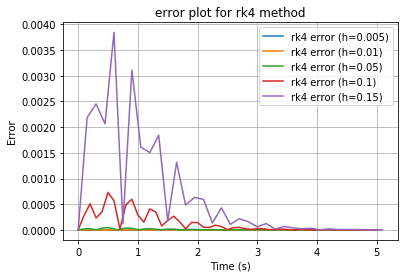

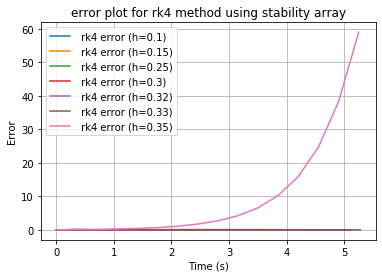

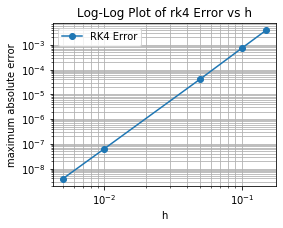

rk4 slope 4.0530194967521025


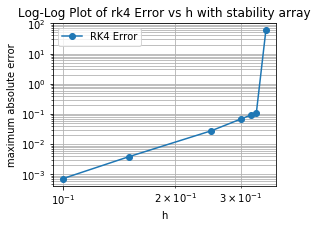

In [112]:
# error for rk4
for h in h_arr_2:
    y0_vec5 = np.array([y0, v0])
    t_vals5, y_vals5 = rk4(f, y0_vec5, t_start, t_end, h)
    exact_sol1 = y_exact(t_vals5)
    error = np.abs(exact_sol1 - y_vals5[:, 0])
    plt.plot(t_vals5, error, label=f"rk4 error (h={h})")
    
# setting up good plot
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("error plot for rk4 method")
plt.legend()
plt.grid(True)
plt.show()
for h in h_arr_stability23:
    t_vals6, y_vals6 = rk4(f, y0_vec, t_start, t_end, h)
    exact_sol2 = y_exact(t_vals6)
    error2 = np.abs(exact_sol2 - y_vals6[:, 0])

    plt.plot(t_vals6, error2, label=f" rk4 error (h={h})")
    
# setting up good plot
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("error plot for rk4 method using stability array")
plt.legend()
plt.grid(True)
plt.show()

#add log-log plot
rk4_max_errors = []
for h in h_arr_2:
    t_vals7, y_vals7 = rk4(f, y0_vec, t_start, t_end, h)
    exact_sol3 = y_exact(t_vals7)
    error = np.abs(exact_sol3 - y_vals7[:, 0])
    max_error = np.max(error)
    rk4_max_errors.append(max_error)

plt.figure(figsize=(4, 3))
plt.loglog(h_arr_2, rk4_max_errors, marker='o', label="RK4 Error")
plt.xlabel("h")
plt.ylabel("maximum absolute error")
plt.title("Log-Log Plot of rk4 Error vs h")
plt.legend()
plt.grid(True, which="both")
plt.show()
rk4_slope, _ = np.polyfit(np.log(h_arr_2), np.log(rk4_max_errors), 1)
print("rk4 slope", rk4_slope)

rk4_max_errors1 = []
for h in h_arr_stability23:
    t_vals8, y_vals8 = rk4(f, y0_vec, t_start, t_end, h)
    exact_sol4 = y_exact(t_vals8)
    error2 = np.abs(exact_sol4 - y_vals8[:, 0])
    max_error2 = np.max(error2)
    rk4_max_errors1.append(max_error2)

plt.figure(figsize=(4, 3))
plt.loglog(h_arr_stability23, rk4_max_errors1, marker='o', label="RK4 Error")
plt.xlabel("h")
plt.ylabel("maximum absolute error")
plt.title("Log-Log Plot of rk4 Error vs h with stability array")
plt.legend() 
plt.grid(True, which="both")
plt.show()

### Error analysis of the RK4 system

For all the stable approximations, the error plots showed a little bit of oscillatory behavior but error eventually converged to a very small magnitude. This makes sense as these approximations were stable. However, for unstable approximations, the error plots followed the original plots as position seems to follow an exponential function. The lack of a convergence is explained as the step size in these situations are outside of the stability bounds. The log-log plots are very telling as well. The stable approximations had log-log plots that followed a linear relationship where the slope was constant (m = ~4). However, when the approximation became unstable, there seems to be a sharp discontinuity in the slope of the log-log error plot as the transition to the unstable approximation had a sharp uptick in its slope. This makes sense as the error is now exponentially rising and the max error will understandibly be very high. 

### Physical Interpretation of the results

The physical intepretation of the results can be told as a tale of two stories - stable approximations vs unstable approximations. The actual physical system is a damped system where energy should not be conserved.When the approximation is stable, the results show the system oscillating with decreasing amplitude, eventually converging to 0. This makes physical sense given the components of our system, which are both a spring and a damper. While an ideal spring would tend to oscillate forever, the viscous damper will work to reduce the oscillation while there is velocity within the system. The physical interpretation of the situation is aligned with the outputs of the stable approximations, decreasing oscillations, and eventual convergence at zero. However, the unstable approximations told a completely different story, a story that defied the laws of physics. The behavior of the unstable Euler-forward approximation resulted in continued oscillations with increased amplitude. This makes no physical sense as not only is the viscous damper's effect and the behavior of the spring neglected, energy Is artificially poured into the system by the approximation. When the RK4 is outside its stability limits, the solution continues to grow instead of converging to zero. Again, this makes no physical sense as the effects of the damper and the spring are neglected while energy is artificially poured into the system. Overall, the stability of the approximation is directly related to whether the approximation would follow the true physical nature of the system or inject a level of artificiality into the system. 

# Section 6: Conclusion

For our problem, the RK4 method performed much better. Not only did it have a higher step size threshold for maintaining stability, but its error for the same step size was also several orders of magnitude less than that of Euler's forward method. Even with a more complicated implementation, the accuracy advantage of the RK4 method over a wide step size range proves it to be superior to Euler's forward method.

Between the RK4 method and Euler's Forward method, there are definitely tradeoffs between computational cost and accuracy. The RK4 method, it is highly accurate compared to Euler's Forward. As I noted in the previous section, the absolute error between the analytical solution and the approximation was several orders of magnitude less for the RK4 method compared to Euler's Forward method at the same step size. It also does a better job with stability as it can tolerate higher step sizes than Euler's forward. However, it ends up being computationally expensive as each step requires 4 function evaluations to calculate the four slopes used in the method. While the RK4 method is highly accurate, it can be computationally expensive. On the other hand, Euler's forward method does a poor job with accuracy compared to the RK4 method. Additionally, its step size tolerance for stability was markedly smaller than the RK4 method, becoming unstable at around h = 0.05. However, it is computationally cheaper per step as it is only evaluates the linear system of equations once per time step. While Euler's forward isn't as effective with accuracy and stability, it is computationally cheaper. The tradeoff between computational cost and accuracy is well displayed in this situation.

From an engineering standpoint, I recommend a few approaches to balance computational cost and accuracy. First, I recommend using an RK4 approximation, as it is better suited for oscillatory mechanical systems. Secondly, I would plot 3 to 4 step sizes that are different enough such that we can find a rough approximation for the stability bounds. After finding that bound, I would multiply it by 1/3 and set that as your step size. Using the error plots from our study, our upper stability bound was h = 0.35. When h = 0.15, the maximum error between the approximation and the analytical solution never exceeded 0.005. This leads us to believe that the error at this step size or below is essentially negligible. Although making the assumption that the error plots can be extrapolated directly to a different system can be misleading, I believe using a factor of 1/3 will bake in enough of a safety factor to maintain accuracy. Additionally, the RK4 method is, anyway, much more accurate than Euler's forward, so accuracy will be preserved regardless, and the step size will be well within the stability bounds. Although computational cost may be high in this situation, the number of steps taken will most likely be less than a stable step size chosen with Euler's forward. Most of the computational cost will come from the 4 function evaluations per iteration and that is a cost that an engineer should be willing to pay for the sake of preserving a high level of accuracy within the system.

One of the key lessons that I learned is that numerical simulations are great tools to use for modeling real-life situations as long as they are within their stability bounds. While the Euler and RK4 methods were within their stability bounds, they performed pretty well, as the general behavior of the analytical solution was also represented in the appropriate step-size Euler and RK4 approximations. Compared to step sizes outside the stability bounds, the approximations with step sizes within the stability bounds had very low error, proving to be a useful tool to represent the given real-world situation. Additionally, of approximations with step sizes outside the stability bounds have behaviors that defy physics. In a system where the mechanical energy of the system is expected to decrease over time as there is a damping presence, unstable approximations seem to oscillate forever or even grow, signifying a strange increase in the mechanical energy of the system.   Another thing I learned that an unstable solution can seem accurate and stable at a smaller time interval, but are bad model in a larger time frame, and instability will always overshadow any early signs of accuracy in the long run. 